# Sesión 1: Regresión en Física (Modelado de Magnitudes Continuas)
**Facilitador: Héctor Martínez | Unidad de Telecomunicaciones - ABAE**

Este cuaderno interactivo guiará los experimentos prácticos del primer bloque del taller. Abordaremos tres problemas progresivos diseñados para entender desde la unidad matemática elemental (la neurona) hasta estructuras de capas profundas aptas para aproximar funciones no lineales complejas.

## Objetivos de Aprendizaje:
1. Comprender el rol del peso ($w$) y el sesgo ($b$) mediante una relación lineal pura.
2. Identificar el impacto de las capas ocultas y funciones de activación (ReLU).
3. Diseñar una arquitectura multivariable evaluando su convergencia con curvas de pérdida (Loss Curves).

In [2]:
# Importación del ecosistema de desarrollo para IA
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print("Versión de TensorFlow en ejecución:", tf.__version__)

Versión de TensorFlow en ejecución: 2.20.0


## 1. Calibración del Sensor de Temperatura de un Satélite (Telemetry Counts a °C)
**Propósito:** Comprender los conceptos de peso ($w$) y sesgo ($b$) aislando el ruido analítico.

Los sistemas de telemetría espacial reciben datos crudos en variables digitales conocidas como *Counts*. La relación física para convertirlos a grados Celsius responde a una calibración puramente lineal:
$$\text{Temperatura (°C)} = w \cdot \text{Counts} + b$$

Entrenaremos una sola neurona para que "descubra" la ganancia ($w$) y el offset ($b$) óptimos basándose únicamente en mediciones históricas, simulando que no poseemos la hoja de datos de calibración del fabricante.

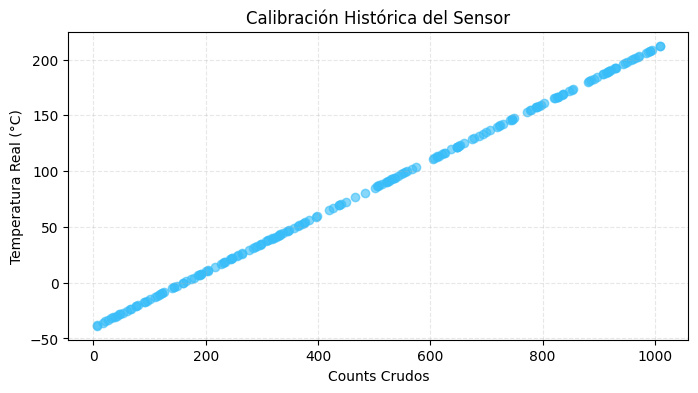

In [ ]:
# Simulación de lecturas históricas (Relación lineal exacta oculta)
# Ecuación real subyacente: Temp = 0.25 * Counts - 40.0
np.random.seed(42)
counts_train = np.random.uniform(0, 1023, 200) # ADC de 10 bits
temp_train = 0.25 * counts_train - 40.0

# Visualización inicial del comportamiento del sensor
plt.figure(figsize=(8, 4))
plt.scatter(counts_train, temp_train, color='#38bdf8', alpha=0.6, label='Datos de Telemetría')
plt.title('Calibración Histórica del Sensor')
plt.xlabel('Counts Crudos')
plt.ylabel('Temperatura Real (°C)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [ ]:
# ==========================================
# ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED
# ==========================================
# Una sola capa densa con 1 nodo y entrada unidimensional
model_sensor = keras.Sequential([
    keras.layers.Dense(units=1, input_shape=[1])
])

# ==========================================
# ETAPA B: PREPARACIÓN PARA LA COMPILACIÓN
# ==========================================
# Configuración del optimizador (Adam) y la función de pérdida para regresión (MSE)
model_sensor.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.5), # Tasa alta debido a la simplicidad del problema
    loss='mean_squared_error'
)

# Entrenamiento del modelo lineal
print("Iniciando ajuste de calibración autónomo...")
history_sensor = model_sensor.fit(counts_train, temp_train, epochs=60, verbose=0)
print("¡Entrenamiento finalizado exitosamente!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando ajuste de calibración autónomo...
¡Entrenamiento finalizado exitosamente!


In [ ]:
# Extracción de los parámetros que la neurona aprendió de forma autónoma
pesos, sesgo = model_sensor.get_weights()
print(f"--> Parámetro w (Peso aprendido por la red): {pesos[0][0]:.4f}  (Valor real teórico: 0.25)")
print(f"--> Parámetro b (Sesgo/Offset aprendido):  {sesgo[0]:.4f} (Valor real teórico: -40.0)")

--> Parámetro w (Peso aprendido por la red): 0.2423  (Valor real teórico: 0.25)
--> Parámetro b (Sesgo/Offset aprendido):  -36.5857 (Valor real teórico: -40.0)


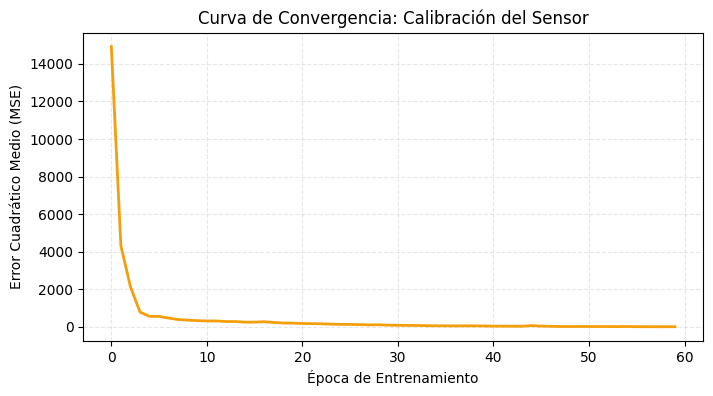

In [ ]:
# Visualización de la convergencia para la calibración del sensor (Sección 1)
plt.figure(figsize=(8, 4))
plt.plot(history_sensor.history['loss'], color='#f59e0b', lw=2)
plt.title('Curva de Convergencia: Calibración del Sensor')
plt.xlabel('Época de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 2. Curva de Saturación y Eficiencia de un Amplificador de Alta Potencia (HPA)
**Propósito:** Demostrar cómo una red neuronal rompe la linealidad utilizando capas ocultas y funciones de activación (**ReLU**), abordando un problema donde la escala nativa de los datos hace innecesaria una capa de normalización.

En las estaciones terrenas de telecomunicaciones espaciales, los Amplificadores de Alta Potencia (HPA) presentan un comportamiento fuertemente no lineal. Cuando el voltaje de la señal de entrada ($X$) es bajo, el componente opera en su **zona lineal** (la eficiencia sube proporcionalmente). Sin embargo, al aproximarse a su punto de compresión, el amplificador entra en **zona de saturación**, provocando que la eficiencia ($Y$) se aplane y forme un techo máximo.

### 💡 Nota sobre la Escala de los Datos:
A diferencia del ejemplo del sensor, aquí las variables de entrada ya operan por su propia naturaleza física en un rango numérico ideal (Voltajes de $0.0$ a $5.0\text{ V}$). Al inyectar magnitudes tan pequeñas, los gradientes matemáticos no corren riesgo de desbordarse, permitiendo que las neuronas procesen los datos crudos directamente sin requerir una capa intermedia de normalización estadística.

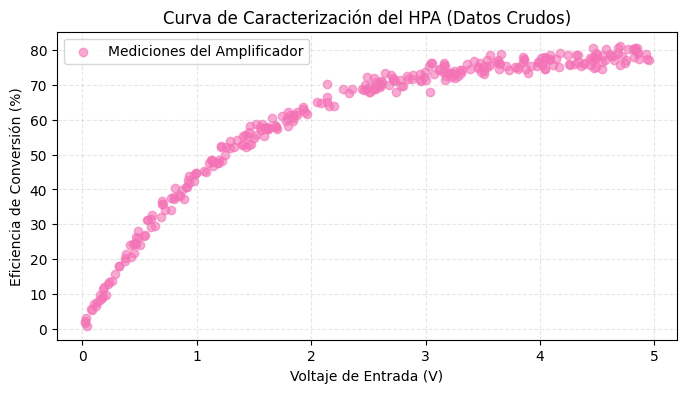

In [3]:

# Simulación de la curva de eficiencia física de un amplificador HPA
# El voltaje (X) opera de 0 a 5 Voltios. La eficiencia (Y) satura exponencialmente cerca del 80%
np.random.seed(42)
voltaje_raw = np.random.uniform(0.0, 5.0, 300)

# Ecuación física de saturación para generar el comportamiento del componente
eficiencia_y = 80.0 * (1.0 - np.exp(-0.8 * voltaje_raw)) + np.random.normal(0, 1.5, 300)

# Ajuste dimensional requerido por Keras para variables de entrada: (Muestras, 1)
voltaje_train_reshaped = voltaje_raw.reshape(-1, 1).astype('float32')

# Visualización del comportamiento del componente de telecomunicaciones
plt.figure(figsize=(8, 4))
plt.scatter(voltaje_raw, eficiencia_y, color='#f472b6', alpha=0.6, label='Mediciones del Amplificador')
plt.title('Curva de Caracterización del HPA (Datos Crudos)')
plt.xlabel('Voltaje de Entrada (V)')
plt.ylabel('Eficiencia de Conversión (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.show()

In [6]:

# =====================================================================
# ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED NO LINEAL (CORREGIDA)
# =====================================================================
model_hpa = keras.Sequential([
    # Usamos 'tanh' para garantizar que las neuronas tengan gradientes activos en todo el rango [0, 5]
    keras.layers.Dense(units=16, activation='tanh', input_shape=[1]),
    keras.layers.Dense(units=8, activation='tanh'),
    # Capa de salida lineal para predecir la eficiencia
    keras.layers.Dense(units=1)
])

# =====================================================================
# ETAPA B: PREPARACIÓN PARA LA COMPILACIÓN Y ENTRENAMIENTO
# =====================================================================
model_hpa.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error'
)

print("Entrenando la red con funciones continuas...")
# Subimos las épocas para asegurar que el optimizador mapée la curva por completo
history_hpa = model_hpa.fit(voltaje_train_reshaped, eficiencia_y, epochs=600, verbose=0)
print("¡Entrenamiento completado!")

Entrenando la red con funciones continuas...
¡Entrenamiento completado!


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


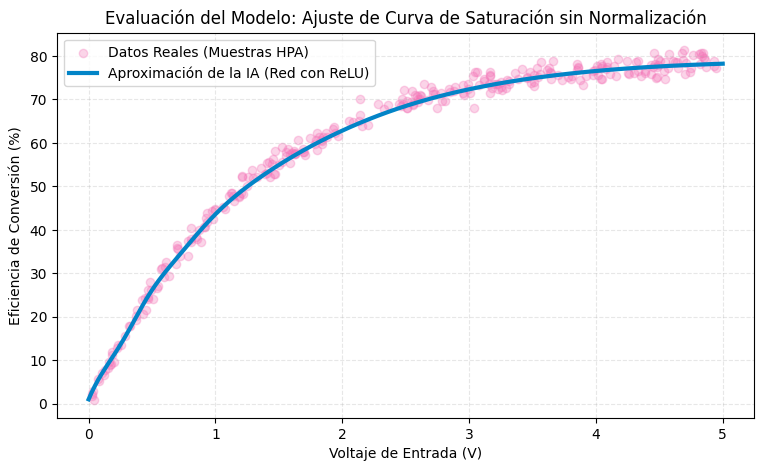

In [7]:

# Generamos un vector ordenado de voltajes de prueba para evaluar la respuesta de la IA
voltaje_test = np.linspace(0.0, 5.0, 200).reshape(-1, 1)
predicciones_eficiencia = model_hpa.predict(voltaje_test)

# Graficado final superponiendo la predicción del modelo sobre los datos reales
plt.figure(figsize=(9, 5))
plt.scatter(voltaje_raw, eficiencia_y, color='#f472b6', alpha=0.3, label='Datos Reales (Muestras HPA)')
plt.plot(voltaje_test, predicciones_eficiencia, color='#0284c7', lw=3, label='Aproximación de la IA (Red con ReLU)')
plt.title('Evaluación del Modelo: Ajuste de Curva de Saturación sin Normalización')
plt.xlabel('Voltaje de Entrada (V)')
plt.ylabel('Eficiencia de Conversión (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 2. Atenuación de Señal en Telecomunicaciones por Pérdida en el Espacio Libre (FSPL)
**Propósito:** Demostrar el impacto de las capas ocultas y funciones de activación cuando la física deja de ser lineal.

La pérdida de potencia de una señal de radiofrecuencia (en dB) a medida que un satélite se desplaza respecto a la estación terrena sigue la ley de la inversa del cuadrado de la distancia. Al expresarse en escala logarítmica, el comportamiento describe una curva. Una neurona lineal simple fallará rotundamente (*underfitting*).

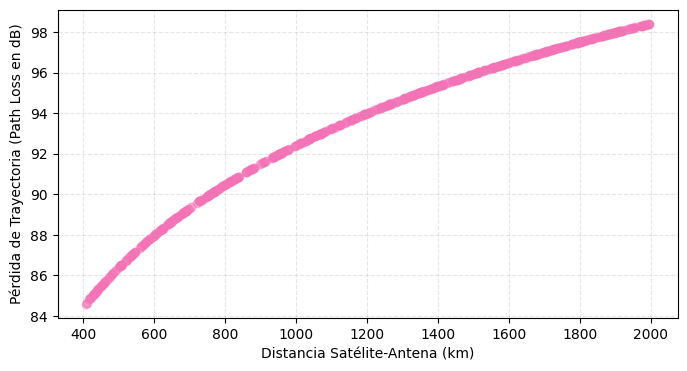

In [8]:
# Simulación de pérdida de trayectoria (Curva logarítmica física)
distancia_train = np.random.uniform(400, 2000, 500) # Kilómetros (Órbita LEO)
# Ecuación física simplificada: FSPL(dB) = 20*log10(d) + Constante
path_loss_train = 20 * np.log10(distancia_train) + 32.4

plt.figure(figsize=(8, 4))
plt.scatter(distancia_train, path_loss_train, color='#f472b6', alpha=0.5, label='Muestras RF')
plt.xlabel('Distancia Satélite-Antena (km)')
plt.ylabel('Pérdida de Trayectoria (Path Loss en dB)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [18]:
# ==========================================
# ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED
# ==========================================
model_rf = keras.Sequential([
    # Usamos 'softplus' para que la red maneje las distancias de miles sin morir
    keras.layers.Dense(units=32, activation='softplus', input_shape=[1]),
    keras.layers.Dense(units=16, activation='softplus'),
    keras.layers.Dense(units=1)
])

# ==========================================
# ETAPA B: PREPARACIÓN PARA LA COMPILACIÓN
# ==========================================
model_rf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['mean_absolute_error'] # Métrica de validación humana complementaria
)

# Ejecución del entrenamiento de la estructura profunda
history_rf = model_rf.fit(distancia_train, path_loss_train, epochs=200, verbose=0)
print("¡Modelo de telecomunicaciones aproximado con éxito!")

¡Modelo de telecomunicaciones aproximado con éxito!


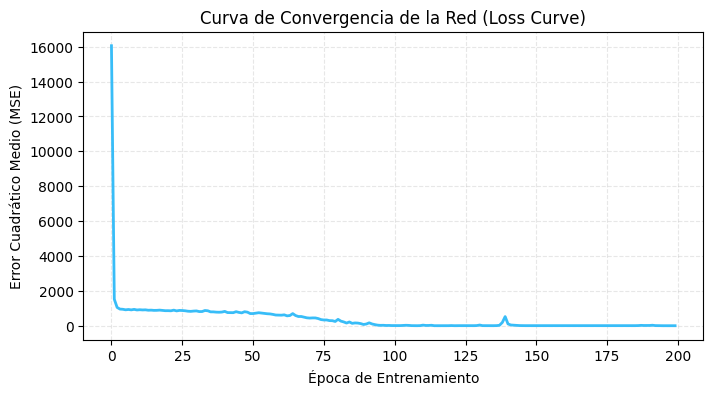

In [19]:
# Graficar la reducción del error a través de las iteraciones (Épocas)
plt.figure(figsize=(8, 4))
plt.plot(history_rf.history['loss'], color='#38bdf8', lw=2)
plt.title('Curva de Convergencia de la Red (Loss Curve)')
plt.xlabel('Época de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


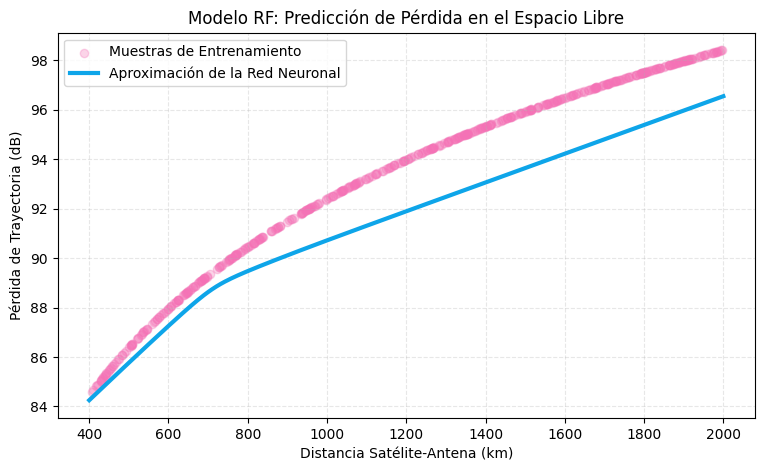

In [20]:
# Generación de predicciones para el modelo de Radiofrecuencia (Sección 2)
distancia_test = np.linspace(400, 2000, 300).reshape(-1, 1)
predicciones_rf = model_rf.predict(distancia_test)

# Visualización de resultados
plt.figure(figsize=(9, 5))
plt.scatter(distancia_train, path_loss_train, color='#f472b6', alpha=0.3, label='Muestras de Entrenamiento')
plt.plot(distancia_test, predicciones_rf, color='#0ea5e9', lw=3, label='Aproximación de la Red Neuronal')
plt.title('Modelo RF: Predicción de Pérdida en el Espacio Libre')
plt.xlabel('Distancia Satélite-Antena (km)')
plt.ylabel('Pérdida de Trayectoria (dB)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 3. Reto Autónomo: Estimación de la Densidad Atmosférica Local en Órbita Baja (LEO)
**Propósito:** Desarrollar intuición en el diseño de redes mediante el uso de múltiples variables de entrada (**Regresión Multivariable**).

**Enunciado:** La densidad de la alta atmósfera decrece exponencialmente con la altitud y varía de forma violenta según el nivel de irradiación o actividad solar, afectando directamente el decaimiento de satélites en órbitas bajas.

Utilizando el set de datos sintéticos preconfigurado en la celda de abajo, tu misión consiste en diseñar, compilar y entrenar una red neuronal capaz de predecir la **Densidad Atmosférica Oculta**.

### Instrucciones Técnicas del Reto:
1. Diseña una red con **al menos dos capas ocultas** interconectadas en la sección de Definición Arquitectónica.
2. Configura un optimizador `Adam` y la función de pérdida pertinente para problemas de estimación continua.
3. Ajusta el número de neuronas e hiperparámetros hasta lograr que la curva de error se estabilice limpiamente cerca de cero sin oscilaciones bruscas.

In [ ]:
# PREPARACIÓN AUTOMÁTICA DEL CONTEXTO DEL RETO (NO MODIFICAR ESTA CELDA)
num_muestras = 1000
altitud = np.random.uniform(200, 600, num_muestras)   # Entrada 1: Altitud en km
act_solar = np.random.uniform(70, 250, num_muestras)  # Entrada 2: Flujo Solar F10.7

# Variable física objetivo calculada de forma no lineal compleja
densidad_objetivo = (1000 / altitud**2) * (act_solar / 100)

# Empaquetamiento matricial de variables de entrada (X)
X_reto = np.column_stack((altitud, act_solar))
Y_reto = densidad_objetivo

print("Estructura dimensional de la matriz de entrada (X):", X_reto.shape)
print("Estructura dimensional del vector objetivo (Y):      ", Y_reto.shape)
print("\n--> ¡Todo listo! Diseña tu arquitectura en la siguiente celda de código.")

In [ ]:
# =====================================================================
# DESARROLLO DEL PARTICIPANTE - COMPLETA LOS BLOQUES DE CÓDIGO
# =====================================================================

# 1. ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED MULTIVARIABLE
model_reto = keras.Sequential([
    # NOTA: La propiedad input_shape ahora debe ser [2] porque procesamos 2 variables de entrada.
    # REQUERIMIENTO: Añade aquí tus capas ocultas densas con funciones de activación ReLU.

    keras.layers.Dense(units=1) # Capa de salida para 1 magnitud continua
])

# 2. ETAPA B: PREPARACIÓN PARA LA COMPILACIÓN
model_reto.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01), # Puedes experimentar con este parámetro
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

# 3. EJECUCIÓN DEL ENTRENAMIENTO (Descomenta la línea de abajo cuando completes tu arquitectura)
# history_reto = model_reto.fit(X_reto, Y_reto, epochs=100, verbose=1)